# Importations

In [40]:
# Numerical and scientific python programming
import numpy as np

from scipy.stats import special_ortho_group
from scipy.optimize import minimize

import matplotlib.pyplot as plt

# Auxiliary python functions
from itertools import combinations, product
from typing import List, Tuple, Dict

# Local importations
from moments.bloch import (generate_gell_mann_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bloch_vector, compute_dm_from_bloch, compute_bloch_norms_from_vector, compute_bloch_norms_from_dm)
from moments.quantum import generate_rand_dm, compute_is_valid_dm
from moments.ent_meas import  compute_negativity
from moments.optimization import opt_moment_preserving_ent

# Definitions

In [2]:
def compute_rand_SO_subset(subset_index_map):
    Q = {}
    for subset in subset_index_map.keys():
        Q[subset] = special_ortho_group.rvs(len(subset_index_map[subset]))
    return Q

def check_tensor_rot(Q):
    for subset in Q.keys():
        if len(subset) > 1:
            Q_tensor = np.array([1])
            for m in subset:
                Q_tensor = np.kron(Q_tensor, Q[(m,)])
            if np.allclose(Q[subset], Q_tensor):
                return False
    return True

In [3]:
dn, N = 3, 2
dim = [dn]*N
d = int(np.prod(dim))

basis = generate_gell_mann_basis(dn)
local_bases = [basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

# Viability test

In [4]:
is_valid = False
j = 0

while not is_valid:
    j += 1
    
    rho = generate_rand_dm(d, d)
    r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

    Q = compute_rand_SO_subset(subset_index_map)
    if not check_tensor_rot(Q):
        print("Warning: Q_M is equal to the tensor product of Q_m for some M")
    
    r_rot = {subset: Q[subset] @ r[subset] for subset in subset_index_map.keys()}
    
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    is_valid, _ = compute_is_valid_dm(rho_rot)

print("Sucess:", is_valid)
print("Number of iterations:", j)

Sucess: True
Number of iterations: 1667


# Local identity rotations

$$
Q_1 = Q_2 = \mathbb I_8
$$

In [5]:
is_valid = False
j = 0

while not is_valid:
    j += 1

    rho = generate_rand_dm(d, d)
    r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

    Q_12 = special_ortho_group.rvs((dn**2-1)**2)
    if np.allclose(Q_12, np.identity((dn**2-1)**2)):
        print("Warning: Q_12 is equal to the tensor product of Q_1 and Q_2 (i.e. the identity).")
    
    r_rot = r.copy()
    r_rot[(1, 2)] = Q_12 @ r_rot[(1, 2)]
    
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    
    is_valid, _ = compute_is_valid_dm(rho_rot)

print("Sucess:", is_valid)
print("Number of iterations:", j)

Sucess: True
Number of iterations: 40001


In [6]:
R = compute_bloch_norms_from_vector(r)
R_rot = compute_bloch_norms_from_vector(r_rot)

bloch_diff = {subset: np.allclose(r[subset], r_rot[subset]) for subset in subset_index_map}
length_diff = {subset: np.allclose(R[subset], R_rot[subset]) for subset in subset_index_map}
DN = abs(compute_negativity(rho = rho) - compute_negativity(rho = rho_rot))

print("One-body Bloch vectors are constant:", (bloch_diff[(1,)] and bloch_diff[(2,)]))
print("Two-body Bloch vector is constant:", bloch_diff[(1, 2)])
print("Density matrix is constant:", np.allclose(rho, rho_rot))
print("Bloch lengths are constant:", all(list(length_diff.values())))
print(f"Negativity difference: {DN:.4f}")

One-body Bloch vectors are constant: True
Two-body Bloch vector is constant: False
Density matrix is constant: False
Bloch lengths are constant: True
Negativity difference: 0.0079


# Test of several methods

In [84]:
def moments_distance(coeff:np.ndarray, tensor_basis: np.ndarray, subset_index_map: Dict[Tuple[int, ...], np.ndarray],
                     E_II: List[np.ndarray], R_target: Dict[Tuple[int, ...], float]) -> float:
    # Compute the density matrix
    rho = np.tensordot(coeff, E_II, axes=(0, 0))

    # Compute Bloch norms
    R = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, rho)
    
    # Compute Bloch norm differences
    loss = 0.0
    for subset, R_M in R.items():
        diff = R_M - R_target[subset]
        loss += diff**2
    
    return float(loss)

def norm_constraint(coeff):
    return np.linalg.norm(coeff) - 1.0

PHI = [np.array([[1], [0], [0]]), np.array([[0], [1], [0]]), np.array([[0], [0], [1]])]
PSI = [np.kron(phi_a, phi_b) for phi_a, phi_b in product(PHI, PHI)]

E_II = np.array([psi @ psi.conj().T for psi in PSI])

cons = {'type': 'eq', 'fun': norm_constraint}

arr = np.random.randn(d) + 1j * np.random.randn(d)
coeff_0 = arr / np.linalg.norm(arr)
Rt = {(1,): 0.5, (2,): 0.5, (1, 2): 1.5}

res = minimize(moments_distance, coeff_0,
               args=(tensor_basis, subset_index_map, E_II, Rt),
               jac=False, method='SLSQP',
               constraints=cons)

print(f"Norm of optimized coeff: {np.linalg.norm(res.x)}")

Norm of optimized coeff: 1.0000000036247456


In [85]:
coeff = res.x
print(coeff)

rho = np.tensordot(coeff, E_II, axes=(0, 0))
r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

is_valid, _ = compute_is_valid_dm(rho)

print("Bloch lengths:\n")
for subset, r in R.items():
    print(f"{subset}: {r**2}")

print("\nIs a valid density matrix?", is_valid)

[ 0.27874717  0.36853301  0.22492311  0.12282795  0.43036497  0.46203441
  0.53545618  0.16589434 -0.08878217]
Bloch lengths:

(1,): 0.24999999999999994
(2,): 0.24999999999999994
(1, 2): 2.2500000000000004

Is a valid density matrix? False


In [ ]:
r = compute_bloch_vector(tensor_basis, subset_index_map, rho)
R = compute_bloch_norms_from_vector(r)
is_valid, _ = compute_is_valid_dm(rho)

N = compute_negativity(rho=rho)

print("Original state:\n")
print(rho)
print("Bloch lengths:\n")
for subset, r in R.items():
    print(f"{subset}: {r**2}")
print(R)

print("\nIs a valid density matrix?", is_valid)
print("Negativity:", N)

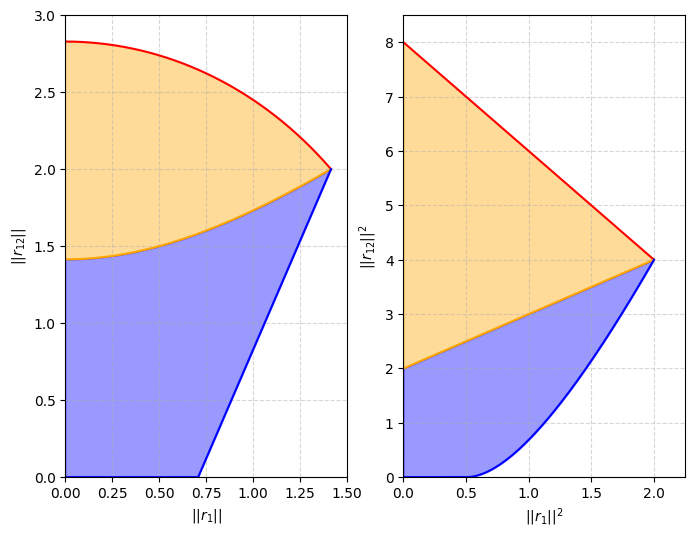

In [9]:
from moments.bloch import compute_bipartite_region_ent, compute_bipartite_region_lower, compute_bipartite_region_upper

x = np.linspace(0, 2 / np.sqrt(2), 1000)

z_upper = compute_bipartite_region_upper(dn, x, x)
z_ent = compute_bipartite_region_ent(dn, x, x)
z_lower = compute_bipartite_region_lower([dn, dn], x, x)

fig, ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].plot(x, z_upper, 'red')
ax[0].plot(x, z_ent, 'orange')
ax[0].plot(x, z_lower, 'blue')

ax[0].fill_between(x, z_upper, z_ent, alpha=0.4, color='orange')
ax[0].fill_between(x, z_ent, z_lower, alpha=0.4, color='blue')

ax[1].plot(x**2, z_upper**2, 'red')
ax[1].plot(x**2, z_ent**2, 'orange')
ax[1].plot(x**2, z_lower**2, 'blue')

ax[1].fill_between(x**2, z_upper**2, z_ent**2, alpha=0.4, color='orange')
ax[1].fill_between(x**2, z_ent**2, z_lower**2, alpha=0.4, color='blue')

ax[0].set(xlabel = r'$||r_1||$', ylabel = r'$||r_{12}||$', xlim = (0, 1.5), ylim = (0, 3))
ax[1].set(xlabel = r'$||r_1||^2$', ylabel = r'$||r_{12}||^2$', xlim = (0, 2.25), ylim = (0, 8.5))
ax[0].grid(True, alpha=0.5, linestyle="--")
ax[1].grid(True, alpha=0.5, linestyle="--")
plt.show()

In [10]:
a, b = 0.5, 1.5
z = np.array([0, 0, 0, 0, 0, 0, 0, 0])/np.sqrt(3)
print(np.linalg.norm(z))
zz = np.kron(z, z)
r = {(1,): a * z, (2,): a * z, (1, 2): b * zz}

rho = compute_dm_from_bloch(tensor_basis, subset_index_map, r)
is_valid, data = compute_is_valid_dm(rho)

print(data)
R = compute_bloch_norms_from_vector(r)

N = compute_negativity(rho=rho)

#print("Original state:\n")
#print(rho)
print("\nIs a valid density matrix?", is_valid)
print("Negativity:", N)

print("\nBloch lengths:\n")
for subset, r in R.items():
    print(f"{subset}: {r:.4f}")

0.0
{'trace': np.float64(1.0), 'trace_ok': np.True_, 'hermitian_ok': True, 'psd_ok': np.True_, 'min_eigenvalue': np.float64(0.1111111111111111)}

Is a valid density matrix? True
Negativity: 0.0

Bloch lengths:

(1,): 0.0000
(2,): 0.0000
(1, 2): 0.0000


In [11]:
run_kwargs = {"dim": dim, "tensor_basis": tensor_basis, "subset_index_map": subset_index_map,
              "optimization": "minimize", "metric": "partial_trace_norm", "cholesky_opt": True, "exact_jac": True}

Rt = {(1,): a, (2,): a, (1, 2): b}
run_kwargs["Rt"] = Rt

optimization_result = opt_moment_preserving_ent(**run_kwargs)
N = compute_negativity(trace_norm_pt=optimization_result.metric_final)
print(f"Metric final: {N:.4f}")
r = optimization_result.bloch_final
print(r)

Metric final: 0.0000
{(1,): array([-1.11636030e-07, -1.22797186e-07,  2.01474604e-01, -5.64418850e-07,
        2.49711612e-07,  3.99201193e-01,  2.29530129e-03, -2.23698732e-01]), (2,): array([ 6.82022778e-07,  1.64778062e-01,  6.78474817e-07,  8.35216736e-07,
        3.82308109e-01,  1.97393408e-07, -3.19585529e-02, -2.75076991e-01]), (1, 2): array([-4.45941899e-13,  5.38616839e-08,  2.66898336e-12, -1.84657553e-12,
        1.24966565e-07, -1.37374995e-12,  4.33652101e-07, -3.46315685e-07,
        8.38973553e-13,  2.45197629e-07,  5.28917578e-12, -5.27209407e-13,
        5.68893698e-07,  9.88441003e-13,  9.79684589e-07, -1.00240621e-06,
        5.49722862e-07,  1.50369927e-01,  8.94107701e-07,  5.87583563e-07,
        3.48879383e-01,  2.49557018e-07,  7.38965283e-03, -2.72128863e-01,
        1.13488308e-12, -1.33368242e-07, -2.58036521e-12, -1.12529778e-12,
       -3.09432741e-07, -4.83691558e-13,  1.31774022e-07,  1.61496801e-07,
        1.18256894e-12, -4.31609585e-09, -2.42708654e-

In [12]:
def iterate_k_nonzero_arrays(k, size, value_range, dtype=np.int64, copy=True):
    if 0 in value_range:
        raise ValueError("value range must not include 0 (need exactly k nonzero entries)")
    
    arr = np.zeros(size, dtype=dtype)

    for idx_tuple in combinations(range(size), k):
        idx = np.fromiter(idx_tuple, dtype=np.intp, count=k)
        for values in product(value_range, repeat=k):
            arr[idx] = values
            yield arr.copy() if copy else arr
        arr[idx] = 0

In [23]:
size, k = 64, 3
value_range = [-2, -1, 1, 2]
indices, results = [], []
negativities = []
a, b = 0.5, 1.5
z = np.array([1, 1, 1, 0, 0, 0, 0, 0])/np.sqrt(3)
r: dict[tuple[int, ...], np.ndarray] = {(1,): a * z, (2,): a * z}

for j, r_nm in enumerate(iterate_k_nonzero_arrays(k, size, value_range, dtype=np.int64, copy=True)):
    
    r_nm = r_nm / np.linalg.norm(r_nm)
    r[(1, 2)] = b * r_nm
    rho = compute_dm_from_bloch(tensor_basis, subset_index_map, r)
    
    is_valid, _ = compute_is_valid_dm(rho)
    if is_valid:
        indices.append(j)
        results.append(r_nm)
        N = compute_negativity(rho)
        negativities.append(N)
        R = compute_bloch_norms_from_vector(r)
        if not np.allclose(list(R.values()), [a, a, b]):
            print("Wrong norms")

if len(results) != 0:
    print("Minimum negativity:", min(negativities))
    print(results[np.argmin(negativities)])
else:
    print("No results")

No results


In [14]:
j = []
for jdx, N in enumerate(negativities):
    if np.isclose(N, 0):
        j.append(jdx)

In [15]:
for jdx in j:
    print(f"{jdx}:\nr_nm = {results[jdx]}")

84035:
r_nm = [-0.57735027  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -0.57735027  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.57735027  0.          0.          0.          0.          0.
  0.          0.          0.          0.        ]
84054:
r_nm = [-0.57735027  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        

In [19]:
a, b = 0.5, 1.5
z = np.array([0, 0, 0, 0, 0, 0, 1, 1])/np.sqrt(2)
#zz = np.zeros((8, 8))
#zz[0, 0], zz[3, 3], zz[6, 6] = [1/np.sqrt(3)]*3
r = {(1,): a * z, (2,): a * z, (1, 2): b * results[0]}

rho = compute_dm_from_bloch(tensor_basis, subset_index_map, r)
is_valid, data = compute_is_valid_dm(rho)
R = compute_bloch_norms_from_vector(r)

N = compute_negativity(rho=rho)

print("Original state:\n")
print(rho)
print("\nIs a valid density matrix?", is_valid)
print("Negativity:", N)

print("\nBloch lengths:\n")
for subset, r in R.items():
    print(f"{subset}: {r:.4f}")

Original state:

[[ 2.62891712e-01+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j -1.44337567e-01+0.j -1.44337567e-01+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  1.66666667e-01+0.j  0.00000000e+00+0.j
  -1.44337567e-01+0.j  0.00000000e+00+0.j -1.44337567e-01+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  1.31445856e-01+0.j
  -1.44337567e-01+0.j -1.44337567e-01+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j -1.44337567e-01+0.j -1.44337567e-01+0.j
   1.66666667e-01+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [-1.44337567e-01+0.j  0.00000000e+00+0.j -1.44337567e-01+0.j
   0.00000000e+00+0.j  7.04416218e-02+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [-1.44337567e-01+0.j -1.44337567e-01+0.j  0.000